In [21]:
import torch, transformers, sklearn, platform
print("Python      :", platform.python_version())
print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("CUDA        :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
else:
    print("\n⚠️  No GPU. Go to Runtime → Change runtime type → T4 GPU, then re-run from the top.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Python      : 3.13.15
torch       : 2.11.0+cu130
transformers: 5.18.0
CUDA        : True
GPU         : Tesla T4


In [54]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

# ---- paths (corrected to use /content/...) ----
PROJECT_DIR = Path("/content/drive/MyDrive/pp1_component1")
DRIVE_DATA  = PROJECT_DIR / "data" / "screenshots"         # contains non_violence / and violence /
OUT_DIR     = PROJECT_DIR / "outputs"
CKPT_DIR    = PROJECT_DIR / "checkpoints" / "violence-vit-screen-ft-v1"
LOCAL_DATA  = Path("/content/data")                       # fast local copy used for training

# ---- classes: (corrected with trailing spaces to match your exact Google Drive folder names) ----
CLASS_NAMES = ["non_violence ", "violence "]

# ---- model ----
BASE_MODEL = "jaranohaal/vit-base-violence-detection"
VIOLENT_IDX_OVERRIDE = None   # leave None: section 3 works out which output = "violent"

# ---- split ----
SEED      = 42
VAL_FRAC  = 0.15
TEST_FRAC = 0.15
# If several screenshots come from the same video/source, they must stay in the SAME split,
# otherwise the test score is inflated. Name files like  <sourceid>_<n>.png  and set GROUP_SEP = "_".
GROUP_SEP = None

# ---- fine-tuning hyper-parameters ----
UNFREEZE_LAST_N = 2      # ViT encoder blocks to unfreeze (plus final layernorm + classifier head)
NUM_EPOCHS      = 5
LEARNING_RATE   = 3e-5   # low LR: we're adapting, not re-learning
BATCH_SIZE      = 16
WEIGHT_DECAY    = 0.01

for d in (OUT_DIR, CKPT_DIR.parent):
    d.mkdir(parents=True, exist_ok=True)
assert DRIVE_DATA.exists(), f"Can't find {DRIVE_DATA} - check the folder layout described at the top."
print("Config OK")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config OK


In [52]:
import os
from pathlib import Path

# Define the target Google Drive path
target_path = Path("/content/drive/MyDrive/pp1_component1/data/screenshots")

print(f"Inspecting path: {target_path}\n")
if target_path.exists():
    # List everything in the root screenshots directory
    contents = os.listdir(target_path)
    print(f"Items found directly inside 'screenshots': {contents}\n")

    # Walk through any subfolders and list files
    for item in contents:
        item_path = target_path / item
        if item_path.is_dir():
            files = [f for f in os.listdir(item_path) if not f.startswith('.')]
            print(f"📁 Subfolder '{item}' contains {len(files)} files:")
            print(f"   Files: {files[:10]}")
            if len(files) > 10:
                print("   ... and more")
else:
    print("❌ The path does not exist. Please check your spelling and structure in Google Drive.")

Inspecting path: /content/drive/MyDrive/pp1_component1/data/screenshots

Items found directly inside 'screenshots': ['raw', 'non_violence ', 'violence ']

📁 Subfolder 'raw' contains 0 files:
   Files: []
📁 Subfolder 'non_violence ' contains 5231 files:
   Files: ['63.jpg', '5109.jpg', '4217.jpg', '1435.jpg', '2896.jpg', '1347.jpg', '5135.jpg', '2128.jpg', '2882.jpg', '1421.jpg']
   ... and more
📁 Subfolder 'violence ' contains 5842 files:
   Files: ['63.jpg', '823.jpg', '2672.jpg', '77.jpg', '5647.jpg', '4565.jpg', '4571.jpg', '3544.jpg', '1347.jpg', '5135.jpg']
   ... and more


In [28]:
# Colab normally has these already; this just makes sure.
!pip -q install accelerate

In [58]:
import shutil, pandas as pd, numpy as np
from PIL import Image

# Force clean the local folder to ensure we get a fresh copy of your newly uploaded Drive images
if LOCAL_DATA.exists():
    print("Cleaning local cache folder to fetch fresh files from Google Drive...")
    shutil.rmtree(LOCAL_DATA)

if not LOCAL_DATA.exists():
    shutil.copytree(DRIVE_DATA, LOCAL_DATA)
    print("Copied dataset to", LOCAL_DATA)

EXTS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}
records, bad = [], []
for label, cls in enumerate(CLASS_NAMES):
    folder = LOCAL_DATA / cls
    if not folder.exists():
        raise AssertionError(
            f"❌ Missing class folder: {folder}\n\n"
            f"Please go to your Google Drive inside 'pp1_component1/data/screenshots/' "
            f"and manually create a folder named '{cls}', then upload your images inside it."
        )
    for p in sorted(folder.rglob("*")):
        if p.suffix.lower() not in EXTS:
            continue
        try:
            with Image.open(p) as im:
                im.verify()
            records.append({"path": p.relative_to(LOCAL_DATA).as_posix(), "label": label})
        except Exception as e:
            bad.append((p.name, repr(e)))

all_df = pd.DataFrame(records)
if not all_df.empty:
    print(all_df["label"].map(dict(enumerate(CLASS_NAMES))).value_counts().to_string())
print(f"Total usable images: {len(all_df)}")
if bad:
    print(f"\nSkipped {len(bad)} unreadable files:")
    for b in bad[:20]:
        print("  ", b)

Cleaning local cache folder to fetch fresh files from Google Drive...
Copied dataset to /content/data
label
violence         5842
non_violence     5231
Total usable images: 11073


In [56]:
from sklearn.model_selection import train_test_split, StratifiedGroupKFold

SPLIT_FILE = OUT_DIR / "splits.csv"

# Ensure we actually have images before attempting a split
if all_df.empty:
    raise ValueError(
        "Your dataset (all_df) is empty! Please make sure you have uploaded actual image files "
        "(.png, .jpg, etc.) to your Drive folders and successfully re-run the previous dataset cell."
    )

def make_split(df):
    df = df.copy()
    if GROUP_SEP is None:
        trval, test = train_test_split(df, test_size=TEST_FRAC, stratify=df["label"], random_state=SEED)
        train, val = train_test_split(trval, test_size=VAL_FRAC / (1 - TEST_FRAC),
                                      stratify=trval["label"], random_state=SEED)
    else:
        groups = df["path"].map(lambda p: Path(p).name.split(GROUP_SEP)[0])
        sgk = StratifiedGroupKFold(n_splits=round(1 / TEST_FRAC), shuffle=True, random_state=SEED)
        trval_idx, test_idx = next(sgk.split(df, df["label"], groups))
        trval, test = df.iloc[trval_idx], df.iloc[test_idx]
        g2 = groups.iloc[trval_idx]
        sgk2 = StratifiedGroupKFold(n_splits=round((1 - TEST_FRAC) / VAL_FRAC), shuffle=True, random_state=SEED)
        tr_idx, val_idx = next(sgk2.split(trval, trval["label"], g2))
        train, val = trval.iloc[tr_idx], trval.iloc[val_idx]
    return pd.concat([train.assign(split="train"), val.assign(split="val"), test.assign(split="test")])

if SPLIT_FILE.exists():
    split_df = pd.read_csv(SPLIT_FILE)
    missing = set(split_df["path"]) - set(all_df["path"])
    new     = set(all_df["path"]) - set(split_df["path"])
    print(f"Re-using existing split from {SPLIT_FILE}")
    if missing or new:
        print(f"⚠️  Dataset changed since the split was made ({len(new)} new, {len(missing)} missing files). "
              "Delete splits.csv and re-run if you want them included - but then re-run the baseline too.")
    split_df = split_df[split_df["path"].isin(set(all_df["path"]))]
else:
    split_df = make_split(all_df)
    split_df.to_csv(SPLIT_FILE, index=False)
    print(f"Created new split → {SPLIT_FILE}")

train_df = split_df[split_df.split == "train"].reset_index(drop=True)
val_df   = split_df[split_df.split == "val"].reset_index(drop=True)
test_df  = split_df[split_df.split == "test"].reset_index(drop=True)
print(pd.crosstab(split_df["split"], split_df["label"].map(dict(enumerate(CLASS_NAMES)))).loc[["train", "val", "test"]])

Created new split → /content/drive/MyDrive/pp1_component1/outputs/splits.csv
label  non_violence   violence 
split                          
train           3661       4090
val              785        876
test             785        876


In [65]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, ViTForImageClassification, set_seed
from huggingface_hub import hf_hub_download
set_seed(SEED)

# 1. Load standard preprocessor fallback
try:
    processor = AutoImageProcessor.from_pretrained(BASE_MODEL)
except Exception as e:
    print("No processor in the model repo, falling back to standard ViT base processor:", e)
    processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

@torch.no_grad()
def predict_probs(model, paths, bs=32):
    model.eval()
    out = []
    for i in range(0, len(paths), bs):
        imgs = [Image.open(LOCAL_DATA / p).convert("RGB") for p in paths[i:i + bs]]
        inputs = processor(images=imgs, return_tensors="pt").to(device)
        out.append(model(**inputs).logits.float().softmax(-1).cpu())
    return torch.cat(out).numpy()

# 2. Reconstruct state dict mapping from timm format to Hugging Face Transformers format manually
def load_mapped_model():
    # Instantiate an uninitialized ViT model matching the base architecture
    model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224-in21k", num_labels=2)

    # Download the checkpoint weights directly
    weights_file = hf_hub_download(repo_id=BASE_MODEL, filename="model.safetensors")
    from safetensors.torch import load_file
    timm_state = load_file(weights_file)

    # Map timm state_dict keys to HF transformers keys
    hf_state = {}
    for k, v in timm_state.items():
        new_key = k
        # Map embeddings
        new_key = new_key.replace("patch_embed.proj.", "vit.embeddings.patch_embeddings.projection.")
        new_key = new_key.replace("pos_embed", "vit.embeddings.position_embeddings")
        new_key = new_key.replace("cls_token", "vit.embeddings.cls_token")

        # Map encoder blocks
        new_key = new_key.replace("blocks.", "vit.encoder.layer.")
        new_key = new_key.replace(".norm1.", ".layernorm_before.")
        new_key = new_key.replace(".norm2.", ".layernorm_after.")
        new_key = new_key.replace(".mlp.fc1.", ".mlp.lin1.")
        new_key = new_key.replace(".mlp.fc2.", ".mlp.lin2.")

        # Map attention components
        new_key = new_key.replace(".attn.proj.", ".attention.output.dense.")

        # Map pooler and classifier head
        new_key = new_key.replace("norm.", "vit.layernorm.")
        new_key = new_key.replace("head.", "classifier.")

        # Map QKV projection matrix split
        if ".attn.qkv." in k:
            base_prefix = new_key.split("attn.qkv.")[0]
            q_w, k_w, v_w = torch.chunk(v, 3, dim=0)
            hf_state[f"{base_prefix}attention.attention.query.{k.split('.')[-1]}"] = q_w
            hf_state[f"{base_prefix}attention.attention.key.{k.split('.')[-1]}"] = k_w
            hf_state[f"{base_prefix}attention.attention.value.{k.split('.')[-1]}"] = v_w
            continue

        hf_state[new_key] = v

    # Load modified state dict
    missing, unexpected = model.load_state_dict(hf_state, strict=False)
    print("Loaded weights map successfully!")
    return model.to(device).eval()

base_model = load_mapped_model()
print("image size:", processor.size, "| mean:", processor.image_mean, "| std:", processor.image_std)

No processor in the model repo, falling back to standard ViT base processor: Unrecognized image processor in jaranohaal/vit-base-violence-detection. Should have a `image_processor_type` key in its preprocessor_config.json of config.json, or one of the following `model_type` keys in its config.json: aria, beit, bit, blip, bridgetower, chameleon, chinese_clip, chmv2, clip, cohere2_vision, cohere_compass, conditional_detr, convnext, cosmos3_edge, deepseek_ocr2, deepseek_vl, deepseek_vl_hybrid, deformable_detr, deit, depth_pro, detr, dinov3_vit, dpt, efficientloftr, efficientnet, eomt, ernie4_5_vl_moe, flava, fuyu, gemma3, gemma4, gemma4_unified, glm46v, glm4v, glm5_next, glm_image, glmga, glpn, got_ocr2, grounding-dino, hunyuan_vl, idefics, idefics2, idefics3, imagegpt, janus, kimi_k25, layoutlmv2, layoutlmv3, levit, lfm2_vl, lightglue, llama4, llava, llava_next, llava_onevision, mask2former, maskformer, minicpmv4_6, minimax_m3_vl, mllama, mobilenet_v1, mobilenet_v2, mobilevit, muse_glimm

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded weights map successfully!
image size: SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None, min_pixels=None, max_pixels=None) | mean: (0.5, 0.5, 0.5) | std: (0.5, 0.5, 0.5)


In [62]:
train_probs_base = predict_probs(base_model, list(train_df["path"]))
y_train = train_df["label"].values
acc_if_1 = ((train_probs_base.argmax(1) == 1) == (y_train == 1)).mean()
acc_if_0 = 1 - acc_if_1
print(f"Train accuracy if output 1 = violent: {acc_if_1:.3f}")
print(f"Train accuracy if output 0 = violent: {acc_if_0:.3f}")

if VIOLENT_IDX_OVERRIDE is not None:
    VIOLENT_IDX = int(VIOLENT_IDX_OVERRIDE)
else:
    VIOLENT_IDX = 1 if acc_if_1 >= acc_if_0 else 0
print(f"\n→ Using model output {VIOLENT_IDX} as 'violent'")
if abs(acc_if_1 - 0.5) < 0.1:
    print("⚠️  Both mappings are close to 50% - the pretrained model barely separates your screenshots. "
          "That's a weak baseline (which is fine to report), but sanity-check a few predictions by eye.")

Train accuracy if output 1 = violent: 0.460
Train accuracy if output 0 = violent: 0.540

→ Using model output 0 as 'violent'
⚠️  Both mappings are close to 50% - the pretrained model barely separates your screenshots. That's a weak baseline (which is fine to report), but sanity-check a few predictions by eye.


In [66]:
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def metrics(y_true, p_violent, thr=0.5):
    y_pred = (p_violent >= thr).astype(int)
    return {
        "n": int(len(y_true)),
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist(),  # rows=true, cols=pred
    }

base_val_p  = predict_probs(base_model, list(val_df["path"]))[:, VIOLENT_IDX]
base_test_p = predict_probs(base_model, list(test_df["path"]))[:, VIOLENT_IDX]
baseline = {"val": metrics(val_df["label"].values, base_val_p),
            "test": metrics(test_df["label"].values, base_test_p)}

with open(OUT_DIR / "baseline_metrics.json", "w") as f:
    json.dump({"model": BASE_MODEL, "violent_output_index": VIOLENT_IDX, **baseline}, f, indent=2)

pd.DataFrame({k: {m: v[m] for m in ["n", "accuracy", "precision", "recall", "f1"]} for k, v in baseline.items()}).round(3)

,val,test
n,1661.000,1661.000
accuracy,0.525,0.525
precision,0.527,0.527
recall,0.966,0.965
f1,0.682,0.682


In [72]:
import copy
import numpy as np
import torch
from transformers import ViTForImageClassification

# Instead of using AutoModel, we copy the architecture and weights from our successfully mapped 'base_model'
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224-in21k", num_labels=2)
model.load_state_dict(base_model.state_dict())

# Re-order the classifier head so index 0 = safe, 1 = violent
if VIOLENT_IDX == 0:
    with torch.no_grad():
        model.classifier.weight.copy_(model.classifier.weight.flip(0).clone())
        model.classifier.bias.copy_(model.classifier.bias.flip(0).clone())
model.config.id2label = {0: "safe", 1: "violent"}
model.config.label2id = {"safe": 0, "violent": 1}

# Freeze everything, then unfreeze the top of the network
for p in model.parameters():
    p.requires_grad = False

# Dynamically locate the list of blocks/layers in the model to avoid AttributeError on different Hugging Face versions
layers_list = None
for name, module in model.named_modules():
    if name.endswith("encoder.layer") or (isinstance(module, torch.nn.ModuleList) and "layer" in name):
        layers_list = module
        break

if layers_list is None:
    # Fallback to standard attributes if the loop didn't capture it
    layers_list = model.vit.encoder.layer if hasattr(model.vit, "encoder") else model.vit.layer

for block in layers_list[-UNFREEZE_LAST_N:]:
    for p in block.parameters():
        p.requires_grad = True

# Safely locate and unfreeze the final layernorm
layernorm_found = False
for name, module in model.named_modules():
    if name.endswith("layernorm") or name.endswith("norm"):
        if "encoder" not in name and "layer." not in name: # Target the final layernorm
            for p in module.parameters():
                p.requires_grad = True
            layernorm_found = True

if not layernorm_found:
    if hasattr(model.vit, "layernorm"):
        for p in model.vit.layernorm.parameters():
            p.requires_grad = True
    elif hasattr(model.vit, "norm"):
        for p in model.vit.norm.parameters():
            p.requires_grad = True

for p in model.classifier.parameters():
    p.requires_grad = True

n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_all   = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {n_train:,} / {n_all:,} ({100 * n_train / n_all:.1f}%)")

# Check the re-ordered model gives identical predictions to the original (before any training)
model.to(device)
chk = predict_probs(model, list(val_df["path"][:16]))[:, 1]
assert np.allclose(chk, base_val_p[:16], atol=1e-4), "Head re-ordering changed predictions - check VIOLENT_IDX"
print("Head re-ordering verified ✓")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 14,178,818 / 85,800,194 (16.5%)
Head re-ordering verified ✓


In [73]:
from torchvision import transforms as T

size = model.config.image_size   # 224 for this ViT
normalize = T.Normalize(mean=processor.image_mean, std=processor.image_std)
train_tf = T.Compose([
    T.RandomResizedCrop(size, scale=(0.7, 1.0), ratio=(0.75, 1.33)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    normalize,
])

class ScreenshotDataset(torch.utils.data.Dataset):
    def __init__(self, frame, train):
        self.frame, self.train = frame.reset_index(drop=True), train
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(LOCAL_DATA / row["path"]).convert("RGB")
        if self.train:
            px = train_tf(img)
        else:  # identical preprocessing to evaluation / live pipeline
            px = processor(images=img, return_tensors="pt")["pixel_values"][0]
        return {"pixel_values": px, "labels": int(row["label"])}

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["labels"] for b in batch])}

train_ds = ScreenshotDataset(train_df, train=True)
val_ds   = ScreenshotDataset(val_df,   train=False)
print(len(train_ds), "train /", len(val_ds), "val")

7751 train / 1661 val


In [74]:
import inspect, math
from transformers import TrainingArguments, Trainer

def hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1": f1_score(labels, preds, zero_division=0),
            "recall": recall_score(labels, preds, zero_division=0)}

# 'evaluation_strategy' was renamed to 'eval_strategy' in newer transformers - support both
_params = inspect.signature(TrainingArguments.__init__).parameters
eval_key = "eval_strategy" if "eval_strategy" in _params else "evaluation_strategy"

steps_per_epoch = math.ceil(len(train_ds) / BATCH_SIZE)
args = TrainingArguments(
    output_dir="/content/runs/violence-ft",
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type="cosine",
    warmup_steps=max(1, int(0.1 * steps_per_epoch * NUM_EPOCHS)),
    save_strategy="epoch",
    logging_steps=max(1, steps_per_epoch // 2),
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
    dataloader_num_workers=2,
    report_to="none",
    seed=SEED,
    **{eval_key: "epoch"},
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                  data_collator=collate, compute_metrics=hf_metrics)

In [75]:
import time
t0 = time.time()
train_result = trainer.train()
train_minutes = (time.time() - t0) / 60
print(f"\nTraining time: {train_minutes:.1f} min")
print("Best checkpoint:", trainer.state.best_model_checkpoint, "| best val F1:", trainer.state.best_metric)

Epoch,Training Loss,Validation Loss,Accuracy,F1,Recall
1,0.644396,0.595559,0.683323,0.709392,0.732877
2,0.572136,0.573035,0.708007,0.762371,0.888128
3,0.531598,0.518677,0.744130,0.754477,0.745434
4,0.526206,0.498194,0.754365,0.770787,0.783105
5,0.517689,0.492645,0.759783,0.773424,0.777397


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before


Training time: 5.7 min
Best checkpoint: /content/runs/violence-ft/checkpoint-2425 | best val F1: 0.7734241908006815


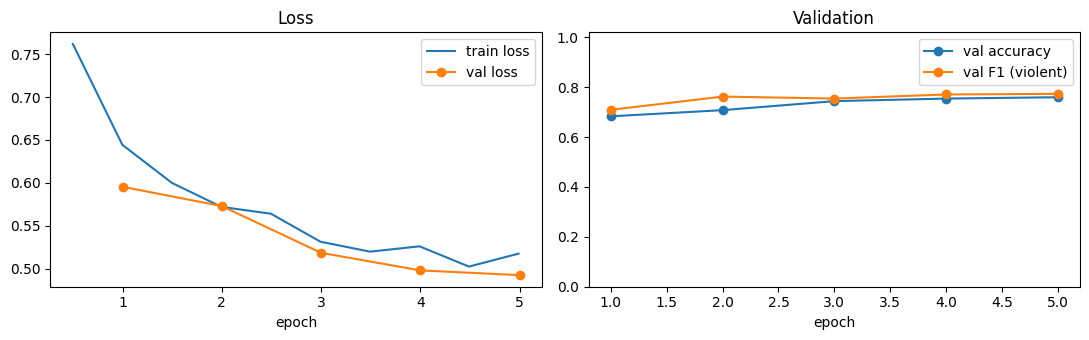

In [76]:
import matplotlib.pyplot as plt
hist = pd.DataFrame(trainer.state.log_history)
tr = hist.dropna(subset=["loss"]) if "loss" in hist else hist.iloc[0:0]
ev = hist.dropna(subset=["eval_loss"])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(tr["epoch"], tr["loss"], label="train loss")
ax[0].plot(ev["epoch"], ev["eval_loss"], "o-", label="val loss")
ax[0].set_xlabel("epoch"); ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(ev["epoch"], ev["eval_accuracy"], "o-", label="val accuracy")
ax[1].plot(ev["epoch"], ev["eval_f1"], "o-", label="val F1 (violent)")
ax[1].set_ylim(0, 1.02); ax[1].set_xlabel("epoch"); ax[1].set_title("Validation"); ax[1].legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "training_curves.png", dpi=150); plt.show()

In [77]:
trainer.save_model(str(CKPT_DIR))       # best epoch (load_best_model_at_end=True)
processor.save_pretrained(str(CKPT_DIR))
print("Saved to", CKPT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/pp1_component1/checkpoints/violence-vit-screen-ft-v1


In [78]:
ft_model = trainer.model.to(device).eval()
ft_val_p  = predict_probs(ft_model, list(val_df["path"]))[:, 1]
ft_test_p = predict_probs(ft_model, list(test_df["path"]))[:, 1]
finetuned = {"val": metrics(val_df["label"].values, ft_val_p),
             "test": metrics(test_df["label"].values, ft_test_p)}
with open(OUT_DIR / "finetuned_metrics.json", "w") as f:
    json.dump({"checkpoint": str(CKPT_DIR), **finetuned}, f, indent=2)

In [79]:
rows = []
for split in ["test", "val"]:
    for m in ["accuracy", "precision", "recall", "f1"]:
        b, a = baseline[split][m], finetuned[split][m]
        rows.append({"split": split, "metric": m, "baseline (pretrained)": round(b, 3),
                     "fine-tuned": round(a, 3), "change (pp)": round(100 * (a - b), 1)})
table = pd.DataFrame(rows)
table.to_csv(OUT_DIR / "before_after.csv", index=False)

md_lines = [f"Violence classifier — baseline `{BASE_MODEL}` vs. screen-domain fine-tuned "
            f"(test n={finetuned['test']['n']}, val n={finetuned['val']['n']})", "",
            "| split | metric | baseline | fine-tuned | change (pp) |", "|---|---|---|---|---|"]
md_lines += [f"| {r['split']} | {r['metric']} | {r['baseline (pretrained)']:.3f} | {r['fine-tuned']:.3f} | {r['change (pp)']:+.1f} |"
             for r in rows]
(OUT_DIR / "before_after.md").write_text("\n".join(md_lines))
table

,split,metric,baseline (pretrained),fine-tuned,change (pp)
0,test,accuracy,0.525,0.753,22.8
1,test,precision,0.527,0.761,23.4
2,test,recall,0.965,0.774,-19.1
3,test,f1,0.682,0.767,8.6
4,val,accuracy,0.525,0.760,23.5
5,val,precision,0.527,0.769,24.2
6,val,recall,0.966,0.777,-18.8
7,val,f1,0.682,0.773,9.1


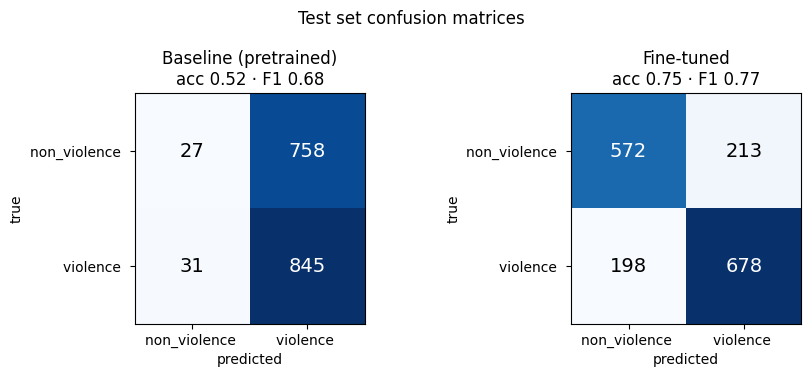

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, (name, res) in zip(axes, [("Baseline (pretrained)", baseline["test"]), ("Fine-tuned", finetuned["test"])]):
    cm = np.array(res["confusion_matrix"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], CLASS_NAMES); ax.set_yticks([0, 1], CLASS_NAMES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{name}\nacc {res['accuracy']:.2f} · F1 {res['f1']:.2f}")
plt.suptitle("Test set confusion matrices"); plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=150); plt.show()

411 / 1661 test images misclassified


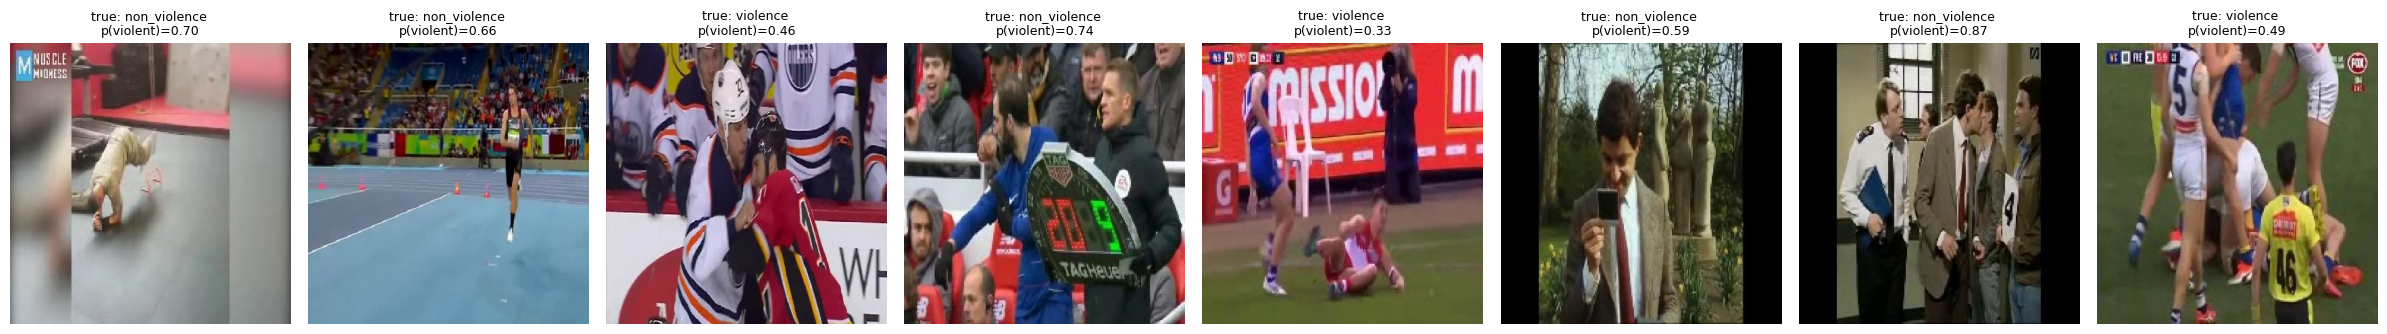

In [81]:
# Which test screenshots does the fine-tuned model still get wrong? (good material for your diary)
test_pred = (ft_test_p >= 0.5).astype(int)
wrong = np.where(test_pred != test_df["label"].values)[0]
print(f"{len(wrong)} / {len(test_df)} test images misclassified")
if len(wrong):
    k = min(8, len(wrong))
    fig, axes = plt.subplots(1, k, figsize=(3 * k, 3.2), squeeze=False)
    for ax, i in zip(axes[0], wrong[:k]):
        ax.imshow(Image.open(LOCAL_DATA / test_df.loc[i, "path"]).convert("RGB")); ax.axis("off")
        ax.set_title(f"true: {CLASS_NAMES[test_df.loc[i, 'label']]}\np(violent)={ft_test_p[i]:.2f}", fontsize=9)
    plt.tight_layout(); plt.savefig(OUT_DIR / "misclassified_test.png", dpi=120); plt.show()

In [82]:
from transformers import pipeline
clf = pipeline("image-classification", model=str(CKPT_DIR), device=0 if torch.cuda.is_available() else -1)
for p in test_df["path"][:3]:
    print(p, "→", clf(str(LOCAL_DATA / p)))

def time_inference(m, dev, n=30):
    m = m.to(dev).eval()
    img = Image.open(LOCAL_DATA / test_df["path"][0]).convert("RGB")
    with torch.no_grad():
        for _ in range(3):  # warm-up
            m(**processor(images=img, return_tensors="pt").to(dev))
        if dev.type == "cuda": torch.cuda.synchronize()
        t = time.perf_counter()
        for _ in range(n):
            m(**processor(images=img, return_tensors="pt").to(dev))
        if dev.type == "cuda": torch.cuda.synchronize()
    return 1000 * (time.perf_counter() - t) / n

latency = {"cpu_ms_per_image": round(time_inference(ft_model, torch.device("cpu"), n=10), 1)}
if torch.cuda.is_available():
    latency["gpu_ms_per_image"] = round(time_inference(ft_model, torch.device("cuda")), 1)
print(latency)
ft_model.to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

non_violence /5111.jpg → [{'label': 'safe', 'score': 0.7613904476165771}, {'label': 'violent', 'score': 0.23860950767993927}]
non_violence /592.jpg → [{'label': 'violent', 'score': 0.7054572701454163}, {'label': 'safe', 'score': 0.29454272985458374}]
non_violence /2665.jpg → [{'label': 'safe', 'score': 0.5586986541748047}, {'label': 'violent', 'score': 0.44130128622055054}]
{'cpu_ms_per_image': 384.0, 'gpu_ms_per_image': 13.0}


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [83]:
import datetime, accelerate
info = {
    "created": datetime.datetime.now().isoformat(timespec="seconds"),
    "base_model": BASE_MODEL,
    "base_violent_output_index": int(VIOLENT_IDX),
    "labels": {0: "safe", 1: "violent"},
    "data": {"train": len(train_df), "val": len(val_df), "test": len(test_df),
             "split_file": "outputs/splits.csv", "seed": SEED, "group_sep": GROUP_SEP},
    "hyperparameters": {"unfreeze_last_n_blocks": UNFREEZE_LAST_N, "epochs": NUM_EPOCHS,
                        "learning_rate": LEARNING_RATE, "batch_size": BATCH_SIZE,
                        "weight_decay": WEIGHT_DECAY, "scheduler": "cosine", "fp16": torch.cuda.is_available(),
                        "trainable_params": int(n_train), "total_params": int(n_all)},
    "best_val_f1": trainer.state.best_metric,
    "training_minutes": round(train_minutes, 1),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "baseline": baseline, "finetuned": finetuned, "colab_latency": latency,
    "versions": {"torch": torch.__version__, "transformers": transformers.__version__,
                 "accelerate": accelerate.__version__},
}
for target in (CKPT_DIR / "training_info.json", OUT_DIR / "training_info.json"):
    with open(target, "w") as f:
        json.dump(info, f, indent=2)

b, a = baseline["test"], finetuned["test"]
print(f'''--- paste into RP diary / supervisor progress note ---
Fine-tuned the violence classifier ({BASE_MODEL}, ViT-base) on {len(train_df)} labelled screen-capture
images (domain adaptation; last {UNFREEZE_LAST_N} encoder blocks + head unfrozen, {NUM_EPOCHS} epochs, lr {LEARNING_RATE},
{info["gpu"]}, {train_minutes:.1f} min).
On the held-out test set (n={a["n"]}):
  accuracy  {b["accuracy"]:.3f} → {a["accuracy"]:.3f}  ({100*(a["accuracy"]-b["accuracy"]):+.1f} pp)
  F1 violent {b["f1"]:.3f} → {a["f1"]:.3f}  ({100*(a["f1"]-b["f1"]):+.1f} pp)
  recall    {b["recall"]:.3f} → {a["recall"]:.3f}
Checkpoint: {CKPT_DIR.name}. Colab single-image inference: {latency}.''')

--- paste into RP diary / supervisor progress note ---
Fine-tuned the violence classifier (jaranohaal/vit-base-violence-detection, ViT-base) on 7751 labelled screen-capture
images (domain adaptation; last 2 encoder blocks + head unfrozen, 5 epochs, lr 3e-05,
Tesla T4, 5.7 min).
On the held-out test set (n=1661):
  accuracy  0.525 → 0.753  (+22.8 pp)
  F1 violent 0.682 → 0.767  (+8.6 pp)
  recall    0.965 → 0.774
Checkpoint: violence-vit-screen-ft-v1. Colab single-image inference: {'cpu_ms_per_image': 384.0, 'gpu_ms_per_image': 13.0}.


In [84]:
# Zip the checkpoint for download / GitHub Release
zip_path = shutil.make_archive(f"/content/{CKPT_DIR.name}", "zip", CKPT_DIR)
shutil.copy(zip_path, CKPT_DIR.parent)
print("Zip saved to Drive:", CKPT_DIR.parent / Path(zip_path).name)
# from google.colab import files; files.download(zip_path)   # uncomment to download directly

Zip saved to Drive: /content/drive/MyDrive/pp1_component1/checkpoints/violence-vit-screen-ft-v1.zip
